# State estimation

Steps 6.2-6.3. What the controller needs at every step: pose, speed, yaw rate and
sideslip. On the car: wheel encoders, gyro, accelerometer and the steering
command. Ground truth: the overhead video of 5.7-5.8.

Session 2026-09-26, after the time sync (6.1) and the IMU fix below. Same setup as
`transients.ipynb`: slicks on tiles, phone 0.5x at ~2 m, cushion ring.

| run | command | what |
|---|---|---|
| steps_imufix | `drive_seq.py` as id_steps: 0.6 m/s, steer 0.40 / 0.52 every 3 s | grip, IMU check |
| drift_imufix | as id_drift: full lock, 0.9 -> 1.3 -> 0.6 m/s | drift |
| square | 0.5 m/s, 2 laps of 1 m straight (steer -0.012) + left turn at full lock | 6.2 |

The seven 5.8 runs are used too: gyro, encoders and video are fine there, the
accelerometer is not.

In [1]:
import sys
sys.path.append('../scripts')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import bagtools as bt
from videotools import load_run, load_track, D_MARK, PINK_BEHIND

plt.rcParams['figure.dpi'] = 72

OLD = ['id_steps', 'id_chirp', 'id_drift', 'val_steps', 'val_chirp', 'val_drift', 'release']
NEW = ['steps_imufix', 'drift_imufix', 'square']

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## IMU fix (issue #74)

In 5.7-5.8 the accelerometer looked useless while driving: std 1-4 m/s², and its
means over 2 s wandered by 1-2 m/s² on a steady circle. The spectrum is red, not a
vibration line, and most published samples repeat the previous one exactly: the
firmware was sending a stale value.

Two causes. The IMU task parsed one SHTP packet per 5 ms poll while the BNO085
produced three reports at 200 Hz. And the SparkFun BNO080 library parses only the
first report of a packet: the BNO085 packs reports that come due together, and the
accelerometer, behind the orientation report, was lost. Fix: read every queued
packet at each poll, and drop the orientation report, which nothing uses.

Share of samples equal to the previous one while the wheels turn (above 10 rad/s),
and the longest run of equal values:

In [2]:
def stale(name):
    d = bt.load(f'../data/{name}_parquet')
    imu, js = d['imu_data_raw'], d['joint_states']
    w = imu[np.interp(imu['t'], js['t'], (js['wl'].abs() + js['wr'].abs()) / 2) > 10]
    same = (w['ax'].diff() == 0).to_numpy()
    longest, n = 0, 0
    for s in same:
        n = n + 1 if s else 0
        longest = max(longest, n)
    return {'accel repeated': same.mean(), 'gyro repeated': (w['gz'].diff() == 0).mean(),
            'longest hold [ms]': 20 * (longest + 1)}


rows = [('id_steps', 'old firmware, driving'), ('id_drift', 'old firmware, driving'),
        ('imu_lifted', 'every packet read, lifted'), ('imu_lifted2', '+ no orientation report, lifted'),
        ('steps_imufix', 'fixed, driving'), ('drift_imufix', 'fixed, driving')]
pd.DataFrame([{'run': n, 'firmware': f, **stale(n)} for n, f in rows]).round(2)

,run,firmware,accel repeated,gyro repeated,longest hold [ms]
0,id_steps,"old firmware, driving",0.61,0.10,800
1,id_drift,"old firmware, driving",0.61,0.09,580
2,imu_lifted,"every packet read, lifted",0.32,0.12,560
3,imu_lifted2,"+ no orientation report, lifted",0.00,0.14,40
4,steps_imufix,"fixed, driving",0.00,0.01,40
5,drift_imufix,"fixed, driving",0.00,0.02,40


Against the video: the 2 s means of the accelerometer on steady segments, and what
the video predicts there: $a = v r$ toward the center, plus the lever arm of the
IMU, 83 mm behind and 22 mm right of the CG ($-r^2\rho$). The accelerometer joins
the aligned tables of 5.8 (same time base); the new runs are aligned the same way.

In [3]:
RHO = np.array([-0.00821 - 0.0744, -0.0225])     # IMU from the CG [m], URDF


def with_accel(df, name):
    d = bt.zero_time(bt.load(f'../data/{name}_parquet'))
    imu = bt.imu_to_vehicle(d['imu_data_raw'])
    imu['t'] -= d['drive']['t'].iloc[0]
    return pd.merge_asof(df, imu[['t', 'ax_v', 'ay_v']], on='t', direction='nearest', tolerance=0.001)


os.makedirs('../data/estimation', exist_ok=True)
runs = {}
for name in OLD:
    runs[name] = with_accel(pd.read_parquet(f'../data/sysid/{name}.parquet'), name)
for name in NEW:
    runs[name] = with_accel(load_run(name)[0], name)
    runs[name].to_parquet(f'../data/estimation/{name}.parquet')


def steady(df):
    seg = ((df['cmd_steer'].diff().abs() > 1e-3) | (df['cmd_speed'].diff().abs() > 1e-2)).cumsum()
    for _, g in df.groupby(seg):
        w = g[g['t'] > g['t'].iloc[0] + 1.0]
        if len(w) >= 75 and g['cmd_speed'].iloc[0] >= 0.3:
            yield w


rows = []
for name in ['id_steps', 'steps_imufix', 'id_drift', 'drift_imufix']:
    e = []
    for w in steady(runs[name]):
        b, v, r = np.radians(w['beta_cg']), w['v_cg'], w['r']
        e.append([w['ax_v'].mean() - (-np.sin(b) * v * r - r**2 * RHO[0]).mean(),
                  w['ay_v'].mean() - (np.cos(b) * v * r - r**2 * RHO[1]).mean()])
    e = np.array(e)
    rows.append({'run': name, 'segments': len(e), 'ax error mean': e[:, 0].mean(), 'ax error sd': e[:, 0].std(),
                 'ay error mean': e[:, 1].mean(), 'ay error sd': e[:, 1].std()})
pd.DataFrame(rows).round(2)

,run,segments,ax error mean,ax error sd,ay error mean,ay error sd
0,id_steps,9,-0.03,1.07,0.35,0.84
1,steps_imufix,9,0.06,0.19,0.28,0.24
2,id_drift,3,0.16,0.34,0.44,0.29
3,drift_imufix,3,0.16,0.09,0.10,0.23


The means now land within 0.1-0.3 m/s² of the video, and their spread is what
white noise of 2.2 m/s² gives over 100 samples. The sample noise itself is the
chassis vibration and stays (std 1.7-2.2 m/s² in grip, 2.4-3.0 in the drift, gyro
0.04-0.05 and 0.17 rad/s): that is what the firmware now puts in the message
covariances, 2.5² and 0.07².

## Baseline: robot_localization (6.2)

`ackermann_bringup/config/ekf.yaml`: 2D, wheel speed and $v_y = 0$ from `/odom`,
yaw rate from the gyro. $v_y = 0$ holds at the rear axle in grip (sideslip there
under 1.5 deg, 5.8) and fails in a drift. The EKF owns `odom -> base_footprint`.

Run offline on the recorded square, with the same launch file as on the car:

    ros2 launch ackermann_bringup robot.launch.py use_lidar:=false use_camera:=false use_sim_time:=true
    ros2 bag record -o data/bags/square_ekf /odometry/filtered /odom --use-sim-time
    ros2 bag play data/bags/square --clock

Compared with the rear axle in the video, both paths moved onto the video at the
start of motion (position and heading).

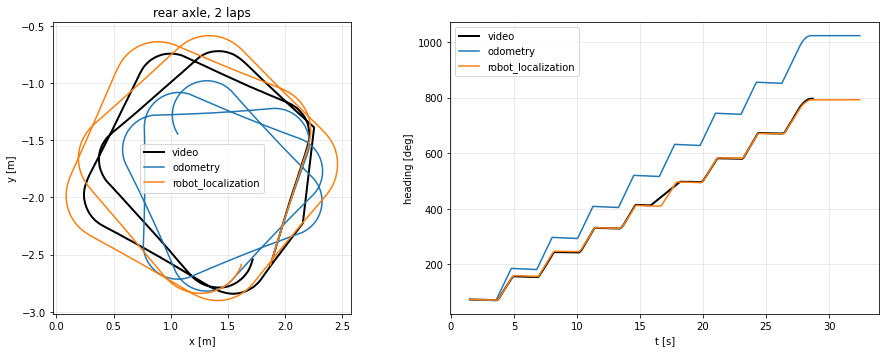

,estimate,heading error end [deg],heading error max [deg],position error end [m],position error max [m]
0,odometry,227.01,227.34,1.28,2.03
1,robot_localization,-3.77,4.62,0.11,0.22


In [4]:
sq, m, off = load_run('square')
t_cmd = bt.load('../data/square_parquet')['drive']['t'].iloc[0]
out = bt.load('../data/bags/square_ekf_parquet')

good = m[m['ok']].copy()
good['t'] += off
k = PINK_BEHIND / D_MARK
scale = good['scale'].median()
good['x'] = (good['pink_x'] + k * (good['green_x'] - good['pink_x'])) * scale
good['y'] = -(good['pink_y'] + k * (good['green_y'] - good['pink_y'])) * scale
good['psi'] = np.unwrap(good['psi'])
start = good[good['t'] > 1.5].iloc[0]

paths, rows = {}, []
for name, key in [('odometry', 'odom'), ('robot_localization', 'odometry_filtered')]:
    d = out[key].copy()
    d['t'] = d['stamp'] - t_cmd
    yaw = np.unwrap(d['yaw'])
    i0 = np.argmin(np.abs(d['t'] - start['t']))
    rot = start['psi'] - yaw[i0]
    x, y = d['x'] - d['x'].iloc[i0], d['y'] - d['y'].iloc[i0]
    d['X'] = start['x'] + np.cos(rot) * x - np.sin(rot) * y
    d['Y'] = start['y'] + np.sin(rot) * x + np.cos(rot) * y
    d['psi'] = yaw + rot
    paths[name] = d
    g = good[good['t'] >= start['t']]
    e_pos = np.hypot(np.interp(g['t'], d['t'], d['X']) - g['x'], np.interp(g['t'], d['t'], d['Y']) - g['y'])
    e_psi = np.degrees(np.interp(g['t'], d['t'], d['psi']) - g['psi'])
    rows.append({'estimate': name, 'heading error end [deg]': e_psi.iloc[-1], 'heading error max [deg]': e_psi.abs().max(),
                 'position error end [m]': e_pos.iloc[-1], 'position error max [m]': e_pos.max()})

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
g = good[good['t'] >= start['t']]
ax[0].plot(g['x'], g['y'], 'k', lw=2, label='video')
ax[1].plot(g['t'], np.degrees(g['psi']), 'k', lw=2, label='video')
for name, d in paths.items():
    d = d[d['t'] >= start['t']]
    ax[0].plot(d['X'], d['Y'], label=name)
    ax[1].plot(d['t'], np.degrees(d['psi']), label=name)
ax[0].set_aspect('equal')
ax[0].set_xlabel('x [m]')
ax[0].set_ylabel('y [m]')
ax[0].set_title('rear axle, 2 laps')
ax[1].set_xlabel('t [s]')
ax[1].set_ylabel('heading [deg]')
for a in ax:
    a.grid(alpha=0.3)
    a.legend()
plt.tight_layout()
plt.show()
pd.DataFrame(rows).round(2)

Odometry alone turns about a third too much and the square collapses: its yaw rate
is $v \tan\delta / L$ with the commanded angle and the wheel speed, and with the
spool the wheels run faster than the car in tight turns. With the gyro the heading
stays within 5 deg over 2 laps and the position within ~0.2 m of ~11 m. What is
left is the speed: the wheels overstate it in the turns, so the filtered square is
slightly larger than the real one.

## Sideslip (6.3)

The model of `system_identification.ipynb`, parameters from `vehicle_params.yaml`,
plus the longitudinal equation:

$$m(\dot v_x - v_y r) = F_{x,L} + F_{x,R} - F_{yf}\sin\delta$$

States $v_x, v_y, r, \delta$; inputs the rear wheel speed $u$ and the steering
command, both known on the car. The tire model has no meaning at standstill (slip
is divided by $u$), so every estimate starts when the wheels pass 0.2 m/s, from
$v_x = u$, $v_y = 0$.

In [5]:
p = yaml.safe_load(open('../ros2_ws/src/ackermann_description/config/vehicle_params.yaml'))['/**']['ros__parameters']
M, IZ, LF, LR, T, G = p['mass'], p['iz'], p['lf'], p['lr'], p['track'], 9.81
NF, NR = M * G * LR / (LF + LR), M * G * LF / (LF + LR)
CMD, DEL = np.array(p['steer_cmd']), np.array(p['steer_angle'])
MU_F, B_F, MU_R, B_R, C, TAU = (p['tire_mu_f'], p['tire_b_f'], p['tire_mu_r'], p['tire_b_r'],
                                p['tire_c'], p['steer_lag'])


def rear_wheel(vx, vy, u):
    sx, sy = (vx - u) / max(u, 0.1), vy / max(u, 0.1)
    s = np.hypot(sx, sy) + 1e-9
    f = MU_R * NR / 2 * np.sin(C * np.arctan(B_R * s))
    return -f * sx / s, -f * sy / s


def forces(x, u):
    vx, vy, r, d = x
    vx = max(vx, 0.05)
    fyf = MU_F * NF * np.sin(C * np.arctan(B_F * (d - np.arctan((vy + LF * r) / vx))))
    fxl, fyl = rear_wheel(vx - T / 2 * r, vy - LR * r, u)
    fxr, fyr = rear_wheel(vx + T / 2 * r, vy - LR * r, u)
    fx = fxl + fxr - fyf * np.sin(d)
    fy = fyf * np.cos(d) + fyl + fyr
    mz = LF * fyf * np.cos(d) - LR * (fyl + fyr) + T / 2 * (fxr - fxl)
    return fx, fy, mz


def f(x, d_cmd, u):
    fx, fy, mz = forces(x, u)
    return np.array([fx / M + x[1] * x[2], fy / M - x[0] * x[2], mz / IZ, (d_cmd - x[3]) / TAU])


def step(x, d_cmd, u, dt, h=0.002):
    n = max(1, round(dt / h))
    for _ in range(n):
        k1 = f(x, d_cmd, u)
        k2 = f(x + dt / n / 2 * k1, d_cmd, u)
        k3 = f(x + dt / n / 2 * k2, d_cmd, u)
        k4 = f(x + dt / n * k3, d_cmd, u)
        x = x + dt / n / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return x


def moving(df):
    return df.iloc[int(np.argmax(df['v_wheels'].fillna(0).to_numpy() > 0.2)):].reset_index(drop=True)


def model(df):
    t, u = df['t'].to_numpy(), df['v_wheels'].interpolate().to_numpy()
    dc = np.interp(df['cmd_steer'].ffill(), CMD, DEL)
    x = np.array([u[0], 0.0, 0.0, dc[0]])
    out = [x]
    for i in range(len(t) - 1):
        x = step(x, dc[i], u[i], t[i + 1] - t[i])
        out.append(x)
    return np.array(out)

**EKF.** The same model predicts, and the IMU corrects: the gyro measures $r$,
the accelerometer measures the forces, $a = F/m$ at the CG plus the lever arm,

$$a_{x,IMU} = \frac{F_x}{m} - \dot r \rho_y - r^2 \rho_x, \qquad
a_{y,IMU} = \frac{F_y}{m} + \dot r \rho_x - r^2 \rho_y$$

$R$ from the firmware covariances, $Q$ mostly on $r$ (where the model is weakest,
5.9). Jacobians by finite differences on the discrete step.

In [6]:
def imu(x, u):
    fx, fy, mz = forces(x, u)
    r, rdot = x[2], mz / IZ
    return np.array([r, fx / M - rdot * RHO[1] - r**2 * RHO[0], fy / M + rdot * RHO[0] - r**2 * RHO[1]])


def ekf(df, use, q=(1e-4, 1e-3, 1e-2, 1e-6), eps=1e-5):
    # use: rows of [gyro, ax, ay] to correct with
    t, u = df['t'].to_numpy(), df['v_wheels'].interpolate().to_numpy()
    dc = np.interp(df['cmd_steer'].ffill(), CMD, DEL)
    z = np.c_[df['r'], df['ax_v'], df['ay_v']][:, use]
    R = np.diag(np.array([0.07**2, 2.5**2, 2.5**2])[use])
    x, P, Q = np.array([u[0], 0.0, df['r'][0], dc[0]]), np.diag([0.01, 0.01, 0.01, 1e-4]), np.diag(q)
    out = [x]
    for i in range(len(t) - 1):
        dt = t[i + 1] - t[i]
        x1 = step(x, dc[i], u[i], dt)
        F = np.column_stack([(step(x + eps * e, dc[i], u[i], dt) - x1) / eps for e in np.eye(4)])
        P = F @ P @ F.T + Q * dt
        h = imu(x1, u[i + 1])[use]
        H = np.column_stack([(imu(x1 + eps * e, u[i + 1])[use] - h) / eps for e in np.eye(4)])
        K = P @ H.T @ np.linalg.inv(H @ P @ H.T + R)
        x = x1 + K @ (z[i + 1] - h)
        P = (np.eye(4) - K @ H) @ P
        out.append(x)
    return np.array(out)

Four estimates of the CG sideslip, against the video. "Rear axle" is what the
6.2 baseline assumes: no sideslip at the rear axle and $v_x$ from the wheels,
$\beta = \arctan(l_r r / u)$. RMS error in grip and in the drift (rear-axle
sideslip over 10 deg in the video); the accelerometer only for the new runs.

In [7]:
def beta_rms(df, beta):
    ok = df['beta_cg'].notna() & (df['t'] > 2)
    drift = df['beta_rear'].abs() > 10
    e = beta - df['beta_cg']
    return [np.sqrt(np.mean(e[ok & ~drift]**2)), np.sqrt(np.mean(e[ok & drift]**2)) if (ok & drift).any() else np.nan]


est, rows = {}, []
for name in OLD + NEW:
    df = moving(runs[name])
    est[name] = {'rear axle': np.degrees(np.arctan(LR * df['r'] / df['v_wheels'])),
                 'model': np.degrees(np.arctan2(*model(df)[:, [1, 0]].T)),
                 'EKF gyro': np.degrees(np.arctan2(*ekf(df, [0])[:, [1, 0]].T))}
    if name in NEW:
        est[name]['EKF gyro + accel'] = np.degrees(np.arctan2(*ekf(df, [0, 1, 2])[:, [1, 0]].T))
    row = {'run': name}
    for k, b in est[name].items():
        row[k + ' grip'], row[k + ' drift'] = beta_rms(df, b)
    rows.append(row)
pd.DataFrame(rows).set_index('run').round(1)

,rear axle grip,rear axle drift,model grip,model drift,EKF gyro grip,EKF gyro drift,EKF gyro + accel grip,EKF gyro + accel drift
run,,,,,,,,
id_steps,2.9,NaN,1.4,NaN,1.5,NaN,NaN,NaN
id_chirp,2.8,NaN,1.0,NaN,1.0,NaN,NaN,NaN
id_drift,3.1,34.1,1.8,6.3,1.7,12.9,NaN,NaN
val_steps,2.4,NaN,1.6,NaN,1.6,NaN,NaN,NaN
val_chirp,2.2,NaN,1.5,NaN,1.5,NaN,NaN,NaN
val_drift,2.7,31.3,1.5,4.2,1.7,10.5,NaN,NaN
release,2.3,30.3,2.1,6.2,1.7,10.6,NaN,NaN
steps_imufix,2.6,NaN,0.8,NaN,0.8,NaN,0.8,NaN
drift_imufix,2.8,39.3,1.1,8.7,1.1,17.3,1.1,17.4


In grip the model alone is within ~1-2 deg of the video (part of it the constant
~1 deg offset of 5.9), about half the rear-axle error. In the drift the rear-axle
assumption is off by 30-40 deg, the model by 4-9 deg, and the corrections make it
worse, the accelerometer included.

The reason shows in the four drifts, all with the same commands:

In [8]:
rows = []
for name in ['id_drift', 'val_drift', 'release', 'drift_imufix']:
    df = runs[name]
    w = df[df['beta_rear'].abs() > 10]
    rows.append({'run': name, 'yaw rate gyro [rad/s]': w['r'].mean(), 'v CG video [m/s]': w['v_cg'].mean(),
                 'a = v r [m/s2]': (w['v_cg'] * w['r']).mean(), 'beta CG video [deg]': w['beta_cg'].mean()})
pd.DataFrame(rows).round(2)

,run,yaw rate gyro [rad/s],v CG video [m/s],a = v r [m/s2],beta CG video [deg]
0,id_drift,3.51,0.52,1.83,-19.85
1,val_drift,3.47,0.53,1.86,-17.07
2,release,3.34,0.58,1.92,-16.56
3,drift_imufix,3.43,0.47,1.62,-25.12


Yaw rate within 5% and acceleration within 15% across the four, sideslip from -17
to -25 deg. Once the tires slide their force stays near $\mu N$ whatever the slip
angle, so the gyro and the accelerometer barely depend on $\beta$: in a steady
drift it is close to unobservable from the IMU. The model then gives the drift it
was fitted on, and a filter that forces it onto the measured yaw rate moves
$v_y$ along a wrong direction.

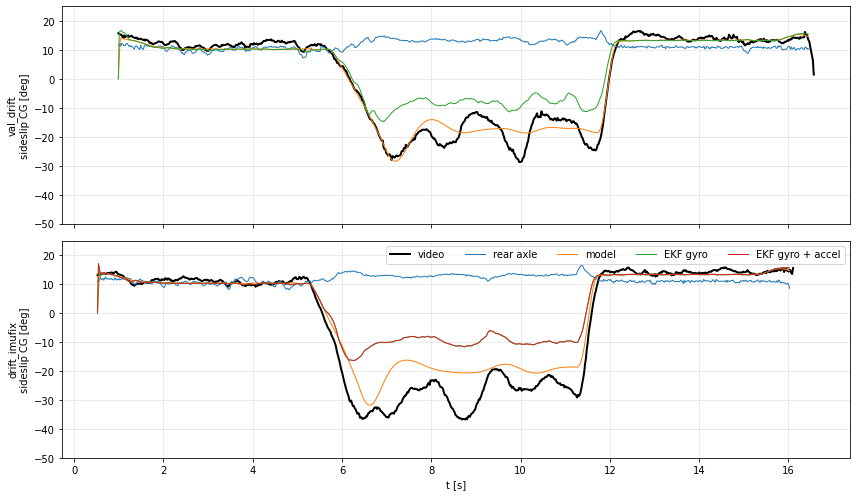

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for a, name in zip(ax, ['val_drift', 'drift_imufix']):
    df = moving(runs[name])
    mv = df['v_wheels'] > 0.2
    a.plot(df['t'], df['beta_cg'], 'k', lw=2, label='video')
    for k, b in est[name].items():
        a.plot(df['t'][mv], b[mv], lw=1, label=k)
    a.set_ylim(-50, 25)
    a.set_ylabel(f'{name}\nsideslip CG [deg]')
    a.grid(alpha=0.3)
ax[1].legend(ncol=5)
ax[1].set_xlabel('t [s]')
plt.tight_layout()
plt.show()

## Result

- IMU: the accelerometer was a stale copy of itself (60% repeated samples, up to
  1.3 s). Fixed in the firmware, its means now match the video within 0.1-0.3 m/s².
- robot_localization with wheel speed and gyro: heading within 5 deg and position
  within ~0.2 m over 2 laps of a 1.6 m square, where odometry alone is 227 deg off.
- Sideslip: the model driven by wheel speed and steering is the best estimate,
  ~1-2 deg in grip and 4-9 deg in the drift. The IMU cannot improve it in the
  drift: yaw rate and acceleration do not depend on $\beta$ once the tires slide.

To measure $\beta$ in a drift the car needs the direction of its velocity. The
lidar localization of Phase 7 gives it (velocity in the map frame against the
heading).